In [1]:
%matplotlib inline

100%|█████████████████████████████████████████████████████████████████████████████| 40000/40000 [08:59<00:00, 74.20it/s]


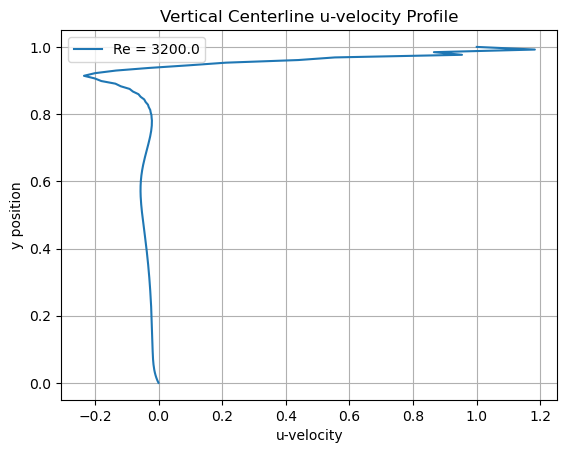

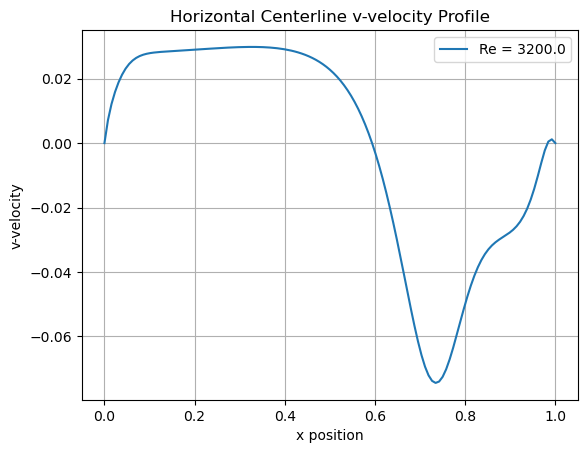

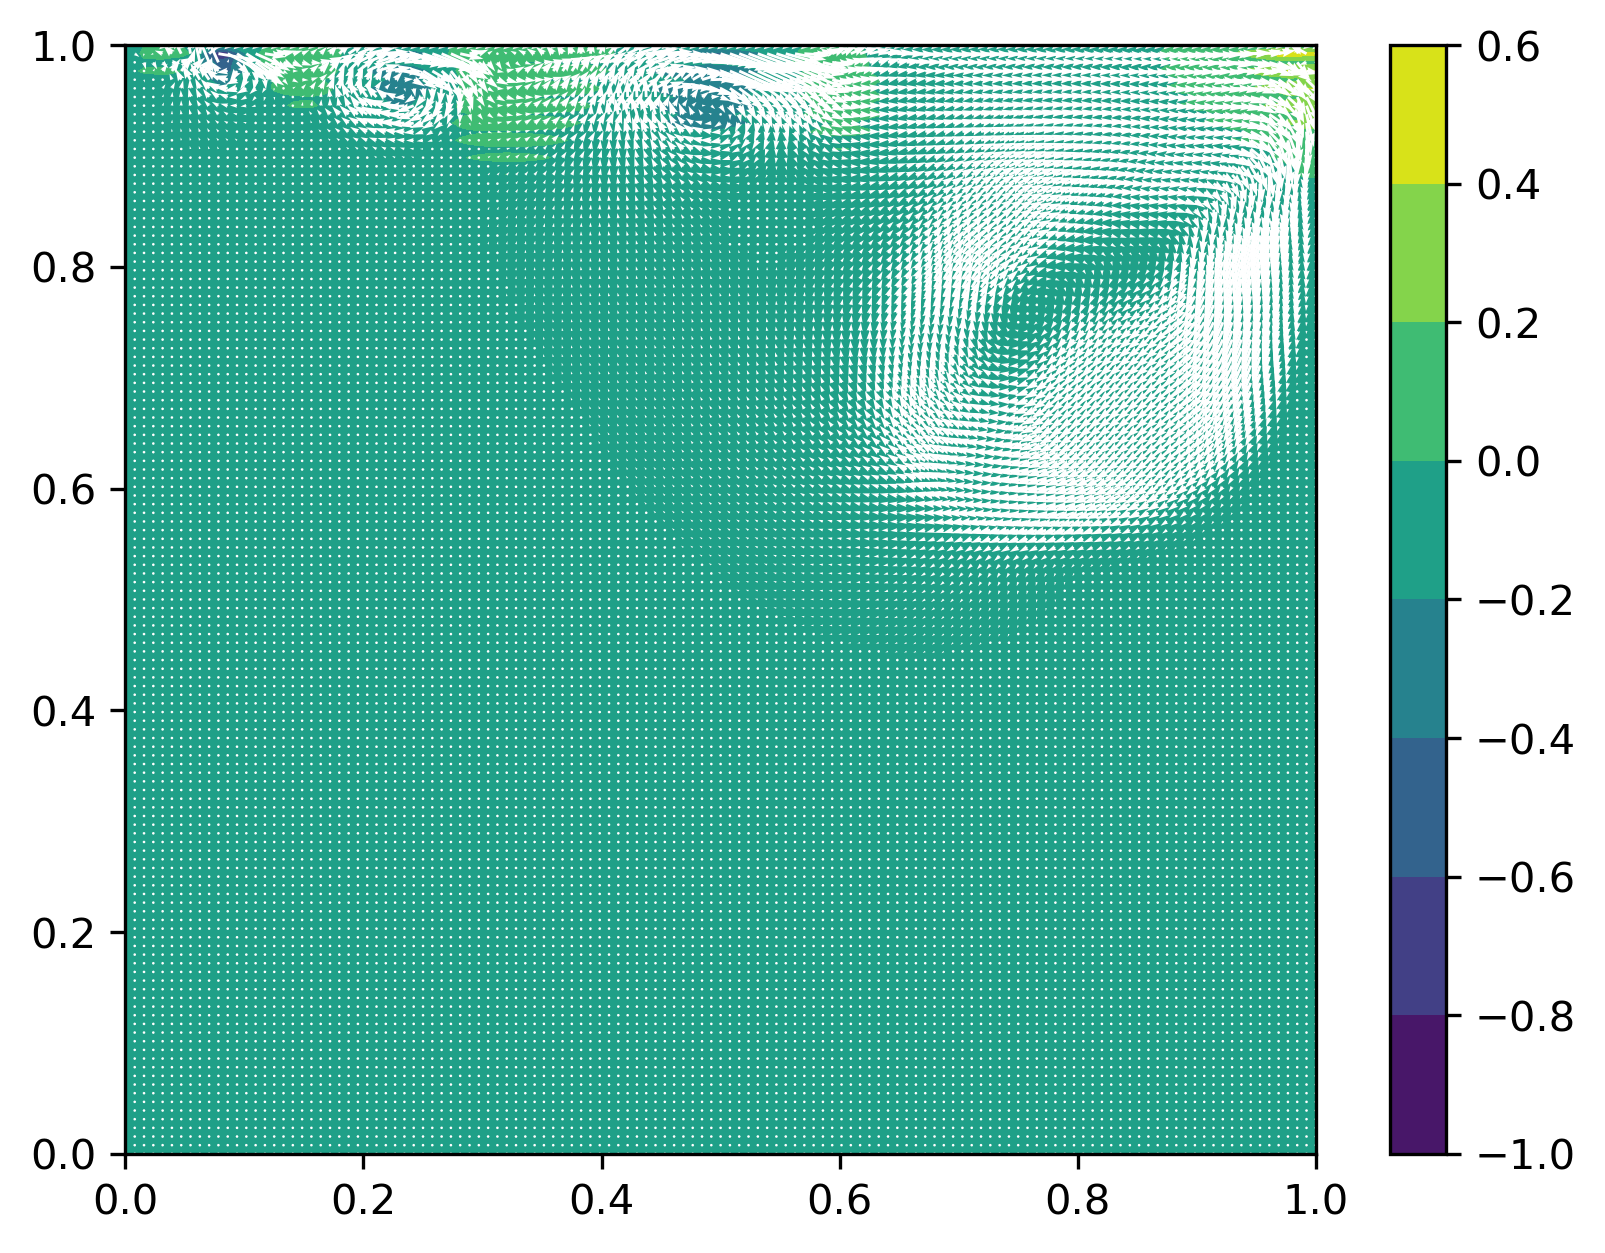

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm              

N_POINTS = 129
DOMAIN_SIZE = 1.0
TIME_STEP_LENGTH = 0.0001
N_ITERATIONS = 40000
DENSITY = 1.0
HORIZONTAL_VELOCITY_TOP = 1.0
KINEMATIC_VISCOSITY = 0.0003125
N_PRESSURE_POISSON_ITERATIONS = 128
Re = (HORIZONTAL_VELOCITY_TOP * DOMAIN_SIZE) / KINEMATIC_VISCOSITY

def main():
    element_length = DOMAIN_SIZE / (N_POINTS - 1)
    x = np.linspace(0.0, DOMAIN_SIZE, N_POINTS)
    y = np.linspace(0.0, DOMAIN_SIZE, N_POINTS)

    X, Y = np.meshgrid(x, y)

    u_prev = np.zeros_like(X)    
    v_prev = np.zeros_like(X)
    p_prev = np.zeros_like(X)

    def central_difference_x(f):
        diff = np.zeros_like(f)
        diff[1:-1, 1:-1] = (
            f[1:-1, 2:  ]
            -
            f[1:-1, 0:-2]
        ) / (
            2 * element_length
        )
        return diff

    def central_difference_y(f):
        diff = np.zeros_like(f)
        diff[1:-1, 1:-1] = (
            f[2:  , 1:-1]
            -
            f[0:-2, 1:-1]
        ) / (
            2 * element_length
        )
        return diff

    def laplace(f):
        diff = np.zeros_like(f)
        diff[1:-1, 1:-1] = (
            f[1:-1, 0:-2]
            +
            f[0:-2, 1:-1]
            - 4 *
            f[1:-1, 1:-1]
            +
            f[1:-1, 2:  ]
            +
            f[2:  , 1:-1]
        ) / (
            element_length**2
        )
        return diff

    for i in tqdm(range(N_ITERATIONS)):
        if np.any(np.isnan(u_prev)) or np.any(np.isinf(u_prev)):
            print(f"u overflow at iteration {i}")
            break
        if np.any(np.isnan(v_prev)) or np.any(np.isinf(v_prev)):
            print(f"v overflow at iteration {i}")
            break
        if np.any(np.isnan(p_prev)) or np.any(np.isinf(p_prev)):
            print(f"p overflow at iteration {i}")
            break
            
        d_u_prev__d_x = central_difference_x(u_prev)
        d_u_prev__d_y = central_difference_y(u_prev)
        d_v_prev__d_x = central_difference_x(v_prev)
        d_v_prev__d_y = central_difference_y(v_prev)
        laplace__u_prev = laplace(u_prev)
        laplace__v_prev = laplace(v_prev)

        # Tentative velocity step: solve momentum equation without pressure gradient
        u_tent = (
            u_prev
            +
            TIME_STEP_LENGTH * (
                -
                (
                    u_prev * d_u_prev__d_x
                    +
                    v_prev * d_u_prev__d_y
                )
                +
                KINEMATIC_VISCOSITY * laplace__u_prev
            )
        )
        v_tent = (
            v_prev
            +
            TIME_STEP_LENGTH * (
                -
                (
                    u_prev * d_v_prev__d_x
                    +
                    v_prev * d_v_prev__d_y
                )
                +
                KINEMATIC_VISCOSITY * laplace__v_prev
            )
        )

        # Velocity BCs: no-slip on walls, driven lid at top
        u_tent[0, :] = 0.0
        u_tent[:, 0] = 0.0
        u_tent[:,-1] = 0.0
        u_tent[-1,:] = HORIZONTAL_VELOCITY_TOP
        v_tent[0, :] = 0.0
        v_tent[:, 0] = 0.0
        v_tent[:,-1] = 0.0
        v_tent[-1,:] = 0.0

        d_u_tent__d_x = central_difference_x(u_tent)
        d_v_tent__d_y = central_difference_y(v_tent)

        # Pressure Poisson RHS: enforces incompressibility constraint
        rhs = (
            DENSITY / TIME_STEP_LENGTH
            *
            (
                d_u_tent__d_x
                +
                d_v_tent__d_y
            )
        )

        # Iteratively solve the pressure Poisson equation
        for _ in range(N_PRESSURE_POISSON_ITERATIONS):
            p_next = np.zeros_like(p_prev)
            p_next[1:-1, 1:-1] = 1/4 * (
                +
                p_prev[1:-1, 0:-2]
                +
                p_prev[0:-2, 1:-1]
                +
                p_prev[1:-1, 2:  ]
                +
                p_prev[2: , 1:-1]
                -
                element_length**2
                *
                rhs[1:-1, 1:-1]
            )

            # Pressure BCs: Neumann on walls, Dirichlet at top
            p_next[:, -1] = p_next[:, -2]
            p_next[0,  :] = p_next[1,  :]
            p_next[:,  0] = p_next[:,  1]
            p_next[-1, :] = 0.0

            p_prev = p_next

        d_p_next__d_x = central_difference_x(p_next)
        d_p_next__d_y = central_difference_y(p_next)

        # Correct velocities to enforce incompressibility
        u_next = (
            u_tent
            -
            TIME_STEP_LENGTH / DENSITY
            *
            d_p_next__d_x
        )
        v_next = (
            v_tent
            -
            TIME_STEP_LENGTH / DENSITY
            *
            d_p_next__d_y
        )

        # Velocity BCs: no-slip on walls, driven lid at top
        u_next[0, :] = 0.0
        u_next[:, 0] = 0.0
        u_next[:,-1] = 0.0
        u_next[-1,:] = HORIZONTAL_VELOCITY_TOP
        v_next[0, :] = 0.0
        v_next[:, 0] = 0.0
        v_next[:,-1] = 0.0
        v_next[-1,:] = 0.0

        # Advance in time
        u_prev = u_next
        v_prev = v_next
        p_prev = p_next

    # Extract u-velocity along vertical centerline (x = 0.5) for Ghia et al. comparison
    centerline_idx = N_POINTS // 2
    u_centerline = u_next[:, centerline_idx]
    y_centerline = y

    plt.figure()
    plt.plot(u_centerline, y_centerline, label=f"Re = {Re}")
    plt.xlabel("u-velocity")
    plt.ylabel("y position")
    plt.title("Vertical Centerline u-velocity Profile")
    plt.legend()
    plt.grid()

    # Extract v-velocity along horizontal centerline (y = 0.5) for Ghia et al. comparison
    centerline_idx = N_POINTS // 2
    v_centerline = v_next[centerline_idx, :]
    x_centerline = x

    plt.figure()
    plt.plot(x_centerline, v_centerline, label=f"Re = {Re}")
    plt.xlabel("x position")
    plt.ylabel("v-velocity")
    plt.title("Horizontal Centerline v-velocity Profile")
    plt.legend()
    plt.grid()

    plt.figure(dpi=300)
    plt.contourf(X, Y, p_next)
    plt.colorbar()
    plt.quiver(X, Y, u_next, v_next, color="white")
    # no plt.show() since %matplotlib inline is in the previous cell (for jupyter)

if __name__ == "__main__":
    main()